# Lezione 4 — Dal neurone artificiale al modello non lineare

**Obiettivo:** collegare la teoria su neuroni, sigmoid, gradient descent e MLP a un caso pratico.

## Dataset
Usiamo `make_moons`, un dataset sintetico comodo per mostrare i limiti dei modelli lineari e il ruolo della non linearità.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

## 1) Generazione dati e visualizzazione

In [5]:
X, y = make_moons(n_samples=1000, noise=0.20, random_state=42)
df = pd.DataFrame(X, columns=["x1", "x2"])
df["target"] = y
df.head()

,x1,x2,target
0,-0.111667,0.520224,1
1,1.142650,-0.342577,1
2,0.795558,-0.011442,1
3,0.111827,-0.551932,1
4,-0.816466,0.543996,0


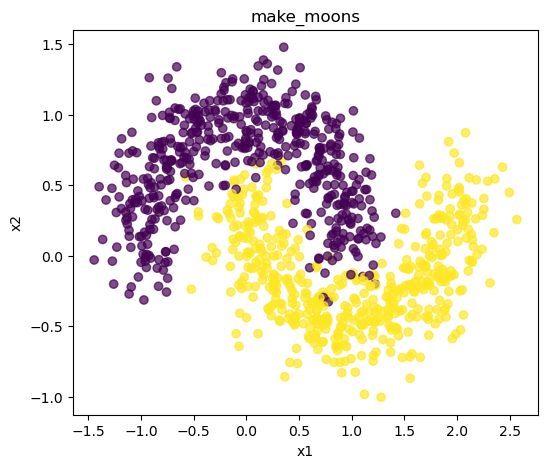

In [6]:
plt.figure(figsize=(6, 5))
plt.scatter(df["x1"], df["x2"], c=df["target"], alpha=0.7)
plt.title("make_moons")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

### Domanda
Osservando il grafico, pensi che un confine **lineare** sia sufficiente?

## 2) Train/Test split + scaling

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df[["x1", "x2"]], df["target"], test_size=0.25, random_state=42, stratify=df["target"]
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 3) Baseline lineare: Logistic Regression

In [8]:
logreg = LogisticRegression()
logreg.fit(X_train_s, y_train)

pred_log = logreg.predict(X_test_s)
acc_log = accuracy_score(y_test, pred_log)
acc_log

0.904

## 4) Modello non lineare: MLP

In [9]:
mlp = MLPClassifier(hidden_layer_sizes=(8, 8), max_iter=2000, random_state=42)
mlp.fit(X_train_s, y_train)

pred_mlp = mlp.predict(X_test_s)
acc_mlp = accuracy_score(y_test, pred_mlp)
acc_mlp

0.984

In [10]:
pd.DataFrame({
    "model": ["Logistic Regression", "MLP (8,8)"],
    "accuracy": [acc_log, acc_mlp]
})

,model,accuracy
0,Logistic Regression,0.904
1,"MLP (8,8)",0.984


## Comunicazione dei risultati

Scrivi una conclusione:
1. Perché il modello lineare fatica?
2. Perché l’MLP migliora?
3. Cosa rappresentano i pesi del neurone?
4. In che senso la non linearità è fondamentale?

## 5) Un neurone singolo da zero (NumPy)

Costruiamo una **regressione logistica** binaria a mano:
- combinazione lineare
- sigmoid
- gradient descent

In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_logreg_numpy(X, y_bin, lr=0.1, epochs=1000):
    Xb = np.c_[np.ones(X.shape[0]), X]  # bias
    w = np.zeros(Xb.shape[1])

    for _ in range(epochs):
        z = Xb @ w
        y_hat = sigmoid(z)
        grad = Xb.T @ (y_hat - y_bin) / len(y_bin)
        w -= lr * grad
    return w

w = train_logreg_numpy(X_train_s, y_train.to_numpy(), lr=0.1, epochs=1000)
w

array([-0.06503484,  1.09646329, -2.32145103])

In [12]:
Xb_test = np.c_[np.ones(X_test_s.shape[0]), X_test_s]
proba = sigmoid(Xb_test @ w)
pred_np = (proba >= 0.5).astype(int)
acc_np = (pred_np == y_test.to_numpy()).mean()
acc_np

0.904

### Interpretazione
Il neurone singolo e la logistic regression hanno entrambi un confine **lineare**.  
L’MLP, invece, grazie agli strati nascosti e alle attivazioni non lineari, può costruire confini più complessi.

## Domande

Scrivi una conclusione:
1. Perché aggiungiamo una colonna di soli 1 prima di moltiplicare per w?
2. Cosa succede se il learning rate è troppo alto o troppo basso?
3. La nostra implementazione usa tutti gli esempi per calcolare il gradiente ad ogni step. come si chiama questo approccio? Esiste un approccio alternaivo?
4. Il nostro neurone raggiunge circa la stessa accuracy della Logistic Regression. Perchè?

In [ ]:
#Esempio di tuning del learning rate

for lr in [0.001, 0.01, 0.1, 1.0,50.0, 100.0]:
    w_lr = train_logreg_numpy(X_train_s, y_train.to_numpy(), lr=lr, epochs=1000)
    Xb_test = np.c_[np.ones(X_test_s.shape[0]), X_test_s]
    proba = sigmoid(Xb_test @ w_lr)
    pred_np = (proba >= 0.5).astype(int)
    acc_np = (pred_np == y_test.to_numpy()).mean()
    print(f"LR: {lr:.3f}, Accuracy: {acc_np:.4f}")

LR: 0.001, Accuracy: 0.8880
LR: 0.010, Accuracy: 0.9000
LR: 0.100, Accuracy: 0.9040
LR: 1.000, Accuracy: 0.9040
LR: 50.000, Accuracy: 0.8200
LR: 100.000, Accuracy: 0.7480
